
# Exploratory Data Analysis

This project explores historical video game sales data to identify trends in genre popularity, regional markets, and publisher competition.

The analysis is designed to demonstrate clean exploratory data analysis (EDA) using Python, pandas, and data visualization libraries.

The dataset contains video game sales from 1980–2016, including regional sales breakdowns for North America, Europe, Japan, and other markets.

## Executive Summary
• Action, Sports, and Shooter games account for the largest share of global sales, suggesting that high-action genres have historically attracted the broadest audiences.

• The global video game market expanded rapidly through the late 1990s and 2000s, reaching peak sales around 2008–2009 before declining in the later years of the dataset.

• North America represents the largest regional market, followed by Europe, while Japan shows a smaller but distinct sales pattern.

• A small number of publishers dominate the industry, with companies such as Nintendo, Electronic Arts, and Activision responsible for a large share of total global sales.

• Video game success is highly concentrated among a small number of blockbuster titles, while the majority of games achieve relatively modest sales.

These patterns highlight the importance of genre selection, regional strategy, and competitive positioning when evaluating opportunities in the video game market.

## Business Context

The analysis is framed around a hypothetical company, GameCo, that wants to understand historical video game sales patterns.

The goal is to explore the data and answer several business questions:

1. Which genres are most popular overall?
2. How have video game sales changed over time?
3. How do regional markets differ?
4. Which publishers appear to be the strongest competitors?

Understanding these patterns can help inform strategic decisions around game development and market targeting.

## Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/vgsales_clean.csv') # Data was cleaned in 'data_cleaning.ipynb' notebook

## Basic Data Inspection

In [3]:
df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
df.shape

(15724, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15724 entries, 0 to 15723
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          15724 non-null  str    
 1   Platform      15724 non-null  str    
 2   Year          15724 non-null  int64  
 3   Genre         15724 non-null  str    
 4   Publisher     15724 non-null  str    
 5   NA_Sales      15724 non-null  float64
 6   EU_Sales      15724 non-null  float64
 7   JP_Sales      15724 non-null  float64
 8   Other_Sales   15724 non-null  float64
 9   Global_Sales  15724 non-null  float64
dtypes: float64(5), int64(1), str(4)
memory usage: 1.2 MB


In [6]:
df.describe()

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,15724.000000,15724.000000,15724.000000,15724.000000,15724.000000,15724.000000
mean,2006.278937,0.271938,0.153208,0.076339,0.049907,0.551652
std,5.841711,0.835942,0.517594,0.310649,0.193303,1.592999
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,2007.000000,0.080000,0.030000,0.000000,0.010000,0.170000
75%,2010.000000,0.240000,0.120000,0.030000,0.040000,0.490000
max,2016.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## Genre Popularity
Understanding which genres generate the most total sales helps identify which types of games historically attract the largest audiences.

In [7]:
# Analyze global sales by genre
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
genre_sales

Genre
Action          1697.92
Sports          1300.59
Shooter         1025.12
Role-Playing     894.58
Platform         825.30
Misc             764.35
Racing           723.70
Fighting         439.31
Simulation       374.87
Puzzle           234.22
Adventure        222.85
Strategy         171.36
Name: Global_Sales, dtype: float64

/var/folders/ch/6n1dbpc97zd0jh39x9fk6lm00000gn/T/ipykernel_84299/3828321184.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='viridis')


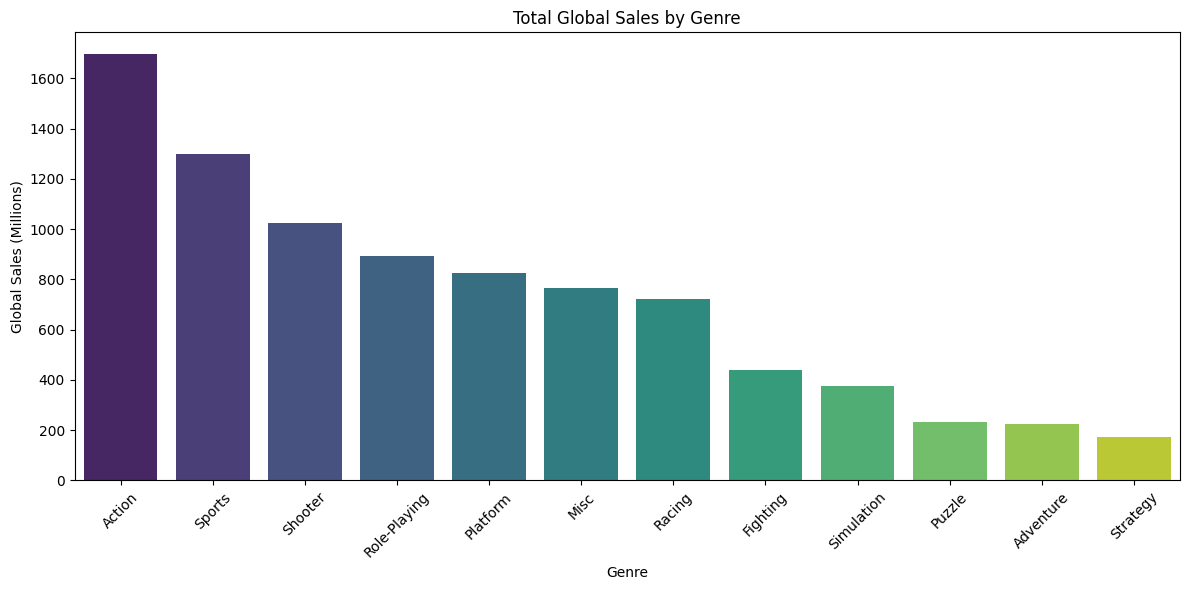

In [8]:
# Create bar plot of global sales by genre
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='viridis')
plt.title('Total Global Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/global_sales_by_genre.png', dpi=300)
plt.show()

**Insight**: Action games generate the highest total global sales, followed by Sports and Shooter titles. These genres appear to have the broadest market appeal across the historical dataset. This suggests that high-action, competitive gameplay has consistently attracted large audiences.

## Sales Trends Over Time
Examining total sales by year helps identify how the video game market has evolved over time.

In [9]:
sales_by_year = df.groupby('Year')['Global_Sales'].sum()

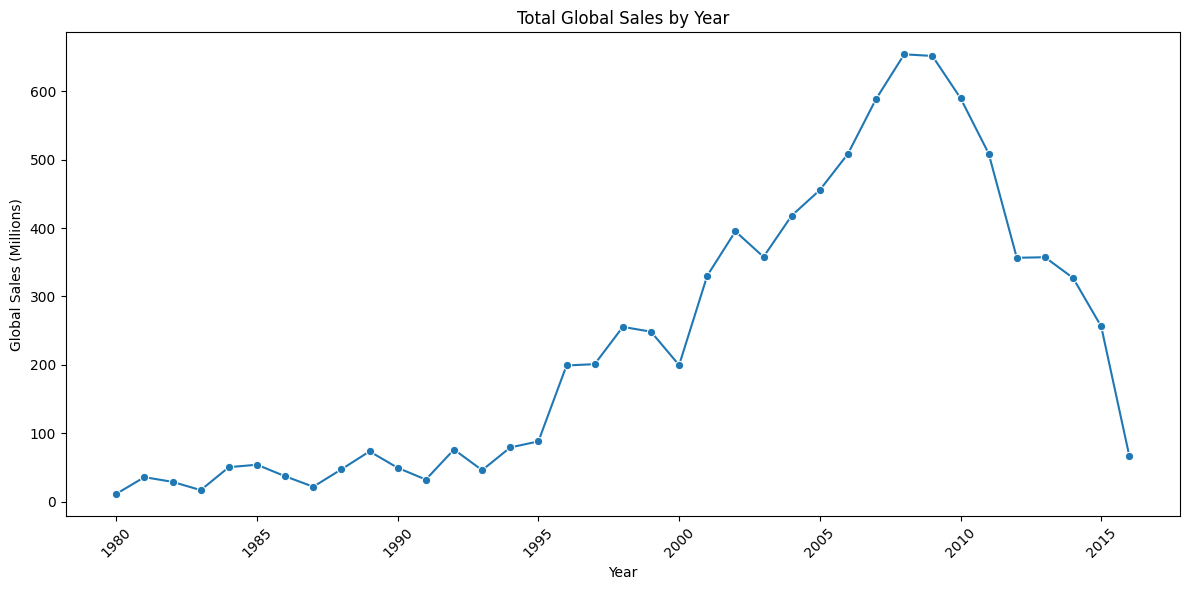

In [10]:
# Create line plot of global sales by year
plt.figure(figsize=(12, 6))
sns.lineplot(x=sales_by_year.index, y=sales_by_year.values, marker='o')
plt.title('Total Global Sales by Year')
plt.xlabel('Year')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/global_sales_by_year.png', dpi=300)
plt.show()

**Insight**: Global video game sales increased steadily throughout the 1990s and early 2000s, reaching a peak around 2008–2009. After this peak, total sales decline in the later years of the dataset. This pattern likely reflects major console generation cycles and changes in the gaming market.

## Regional Market Differences
Regional sales data allows us to compare how demand varies across geographic markets.

In [11]:
region_sales = df.groupby("Year")[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
region_sales.head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Year,,,,
1980,10.59,0.67,0.00,0.12
1981,33.40,1.96,0.00,0.32
1982,26.92,1.65,0.00,0.31
1983,7.76,0.80,8.10,0.14
1984,33.28,2.10,14.27,0.70


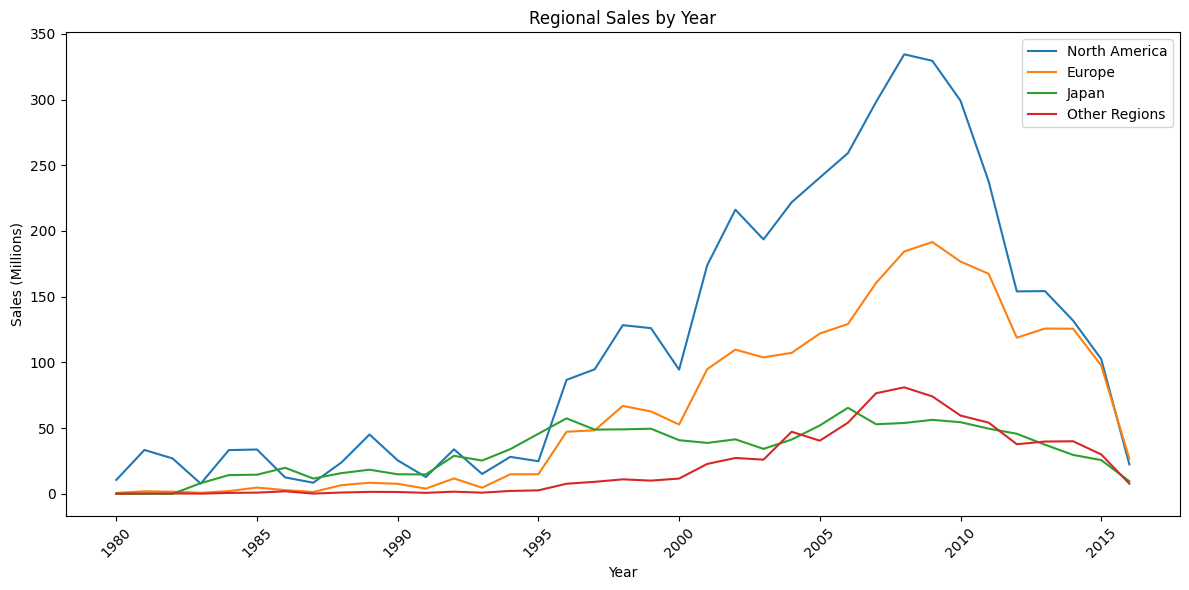

In [12]:
# Create regional sales line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=region_sales, x=region_sales.index, y='NA_Sales', label='North America')
sns.lineplot(data=region_sales, x=region_sales.index, y='EU_Sales', label='Europe')
sns.lineplot(data=region_sales, x=region_sales.index, y='JP_Sales', label='Japan')
sns.lineplot(data=region_sales, x=region_sales.index, y='Other_Sales', label='Other Regions')
plt.title('Regional Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales (Millions)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/regional_sales_by_year.png', dpi=300)
plt.show()

**Insight**: North America represents the largest regional market in the dataset, followed by Europe. Japan shows a smaller but distinct sales pattern compared with Western markets. These differences suggest that regional preferences and market sizes vary significantly across the global gaming industry.

## Publisher Competition
Identifying the publishers with the highest total sales helps highlight major competitors in the video game industry.

In [13]:
publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
publisher_sales

Publisher
Nintendo                        1761.70
Electronic Arts                 1090.00
Activision                       714.21
Sony Computer Entertainment      607.20
Ubisoft                          464.23
Take-Two Interactive             397.94
THQ                              331.10
Konami Digital Entertainment     274.38
Sega                             260.75
Microsoft Game Studios           245.79
Name: Global_Sales, dtype: float64

/var/folders/ch/6n1dbpc97zd0jh39x9fk6lm00000gn/T/ipykernel_84299/3701164257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_sales.index, y=publisher_sales.values, palette='magma')


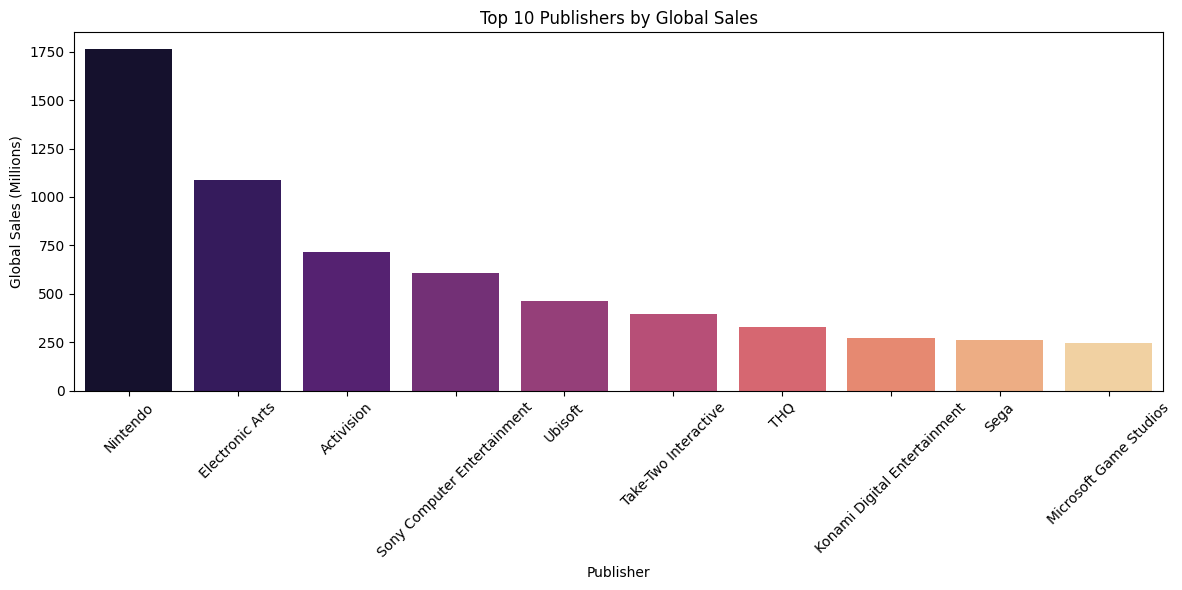

In [14]:
# Create bar plot of global sales by publisher
plt.figure(figsize=(12, 6))
sns.barplot(x=publisher_sales.index, y=publisher_sales.values, palette='magma')
plt.title('Top 10 Publishers by Global Sales')
plt.xlabel('Publisher')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/top_publishers_by_global_sales.png', dpi=300)
plt.show()

**Insight**: A small number of publishers account for a large share of total video game sales. Nintendo leads the market by a significant margin, followed by major companies such as Electronic Arts and Activision. This indicates that the industry is highly competitive but dominated by a few large publishers.

## Distribution of Game Sales
Examining the distribution of global sales helps reveal whether the market is dominated by a few blockbuster titles.

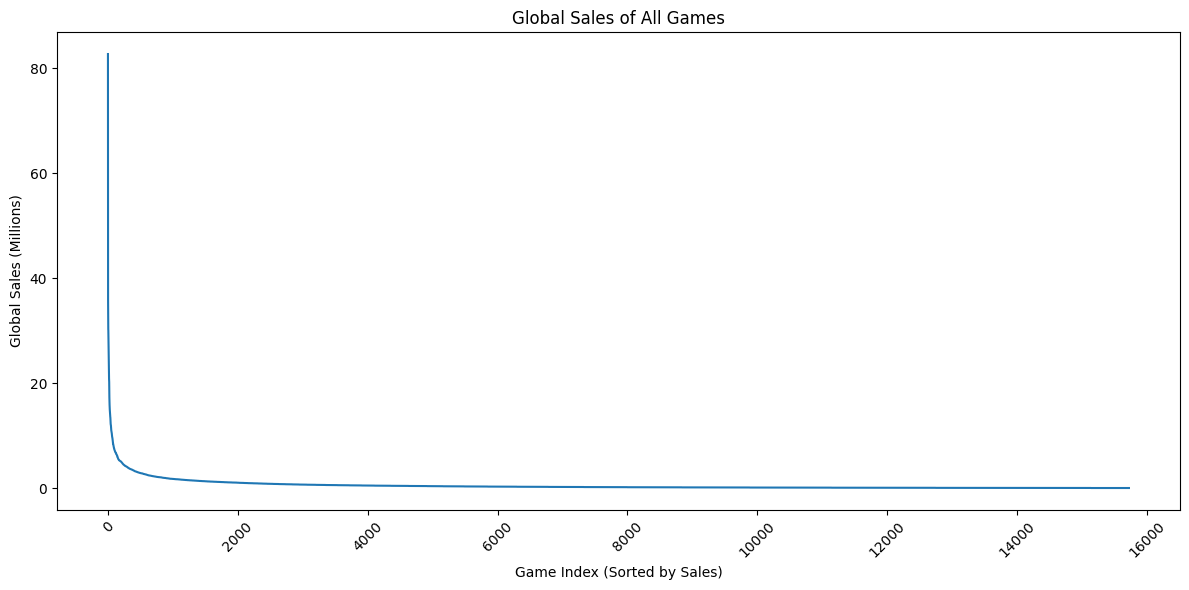

In [15]:
sales_sorted = df.sort_values(by='Global_Sales', ascending=False)

# Create line plot of global sales for all games sorted by sales
plt.figure(figsize=(12, 6))
sns.lineplot(x=sales_sorted.index, y=sales_sorted['Global_Sales'])
plt.title('Global Sales of All Games')
plt.xlabel('Game Index (Sorted by Sales)')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/global_sales_all_games.png', dpi=300)
plt.show()

**Insight**: The ranked sales curve shows a sharp drop-off after the highest-selling games. A small number of blockbuster titles generate extremely large sales, while the majority of games sell relatively modest amounts. This pattern suggests that the video game market is heavily driven by a few major hits.